# Final Project — RAG_LLM Workload Analysis

**Milestone 2: Study energy and latency of an LLM using RAG on a baseline architecture.**

Goals:
1. Model an LLM using RAG on a TPUv4i-like architecture with hard disk
2. Analyze energy and latency while varying **number of documents** and **document size**
3. Identify architectural bottlenecks and which einsums cause them
4. Study prefill vs decode stage characteristics

## Step 1: Imports

In [1]:
import sys
import os

# Make _load_spec.py and scripts/ importable from the workspace root
WORKSPACE_DIR = os.path.dirname(os.path.abspath('.'))
sys.path.insert(0, '/home/workspace/workspace')
sys.path.insert(0, '/home/workspace/workspace/scripts')

import accelforge as af
from _load_spec import get_spec
from utils import Result, round_rank_sizes
from plots import bar_side_by_side, bar_stacked, plot
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict
import pandas as pd
%matplotlib inline

## Step 2: Define Parameters

Edit these dicts to change the RAG_LLM workload size or the architecture configuration.

In [10]:
# RAG_LLM Jinja parameters (passed to workload/RAG_LLM.yaml)
rag_params = {
    # 'VOCAB_SIZE': 32000,  # vocabulary size
    'N_DOCS':     1024,   # number of documents in corpus
    'N_TOKENS':   512,    # query token length
    'K':     10,     # top-k documents retrieved
}

# basic8 Jinja parameters (passed to arch/basic8.yaml)
arch_overrides = {
    'DRAM_SIZE_GB':       8,     # off-chip DRAM capacity in GB
    'DRAM_BW_GBps':       68,    # LPDDR5 bandwidth in GB/s
    'SRAM_SIZE_MB':       8,     # on-chip SRAM capacity in MB
    'SRAM_READ_BW_GBps':  512,   # SRAM read bandwidth in GB/s
    'SRAM_WRITE_BW_GBps': 128,   # SRAM write bandwidth in GB/s
    'MAC_ENERGY_pJ':      0.084, # FP16 MAC energy in pJ
    'MAC_CLOCK_GHz':      1,     # clock frequency in GHz
}

print('RAG_LLM params:', rag_params)
print('Arch overrides:', arch_overrides)

RAG_LLM params: {'N_DOCS': 1024, 'N_TOKENS': 512, 'K': 10}
Arch overrides: {'DRAM_SIZE_GB': 8, 'DRAM_BW_GBps': 68, 'SRAM_SIZE_MB': 8, 'SRAM_READ_BW_GBps': 512, 'SRAM_WRITE_BW_GBps': 128, 'MAC_ENERGY_pJ': 0.084, 'MAC_CLOCK_GHz': 1}


## Step 3: Load the RAG_LLM Workload

In [11]:
WORKLOAD_PATH = '/home/workspace/workspace/workload/full.yaml'

workload = af.Workload.from_yaml(
    WORKLOAD_PATH,
    top_key='workload',
    jinja_parse_data=rag_params,
)
# renames = af.Renames.from_yaml(
#     WORKLOAD_PATH,
#     top_key='renames',
#     jinja_parse_data=rag_params,
# )

print(f'Loaded {len(workload.einsums)} einsums:')
for e in workload.einsums:
    print(f'  {e.name}')

Loaded 25 einsums:
  I
  V
  K
  Q
  QK
  QK_softmax
  AV
  Z
  FFA
  FFB
  CLS
  SIM
  TK
  TK_flat
  II_in
  II
  VV
  KK
  QQ
  QQKK
  QQKK_softmax
  AAV
  ZZ
  FFFA
  FFFB


## Step 4: Run Each Einsum Through the Architecture

Copy operations (`is_copy_operation: True`) will have zero compute energy â€” that is expected.

In [12]:
results = {}

for einsum in workload.einsums:
    print(f'Running {einsum.name}...')
    # basic8 already includes Disk, MainMemory, OnChipSRAM — no dummy memory needed
    spec = get_spec('basic8', add_dummy_main_memory=False, jinja_parse_data=arch_overrides)

    spec.workload = af.Workload(
        einsums=[einsum],
        rank_sizes=workload.rank_sizes,
        bits_per_value=workload.bits_per_value,
        persistent_tensors=workload.persistent_tensors,
    )
    # spec.renames = renames
    spec.mapper.max_pmapping_templates_per_einsum = 1
    round_rank_sizes(spec.workload)
    spec.mapper.metrics = af.mapper.Metrics.ENERGY

    mappings = spec.map_workload_to_arch(print_progress=False, print_number_of_pmappings=False)
    results[einsum.name] = Result(mappings, variables=rag_params)
    print(f'  done — {results[einsum.name].per_compute("energy")*1e12:.2f} pJ/compute')

print('All einsums complete.')

Running I...
  done — 0.00 pJ/compute
Running V...
  done — 8.92 pJ/compute
Running K...
  done — 8.92 pJ/compute
Running Q...
  done — 8.92 pJ/compute
Running QK...
  done — 10.61 pJ/compute
Running QK_softmax...
  done — 233.63 pJ/compute
Running AV...
  done — 10.64 pJ/compute
Running Z...
  done — 8.92 pJ/compute
Running FFA...
  done — 8.81 pJ/compute
Running FFB...
  done — 8.81 pJ/compute
Running CLS...
  done — 123.60 pJ/compute
Running SIM...
  done — 123.49 pJ/compute
Running TK...
  done — 235.93 pJ/compute
Running TK_flat...
  done — 0.00 pJ/compute
Running II_in...
  done — 235.72 pJ/compute
Running II...
  done — 0.00 pJ/compute
Running VV...
  done — 8.49 pJ/compute
Running KK...
  done — 8.49 pJ/compute
Running QQ...
  done — 8.49 pJ/compute
Running QQKK...
  done — 9.32 pJ/compute
Running QQKK_softmax...
  done — 233.63 pJ/compute
Running AAV...
  done — 9.34 pJ/compute
Running ZZ...
  done — 8.49 pJ/compute
Running FFFA...
  done — 8.47 pJ/compute
Running FFFB...
  do

## Step 5: Inspect Results

In [13]:
print(f'{"Einsum":<30} {"pJ/compute":>12}  Per-component energy (fJ/compute)')
print('-' * 80)
for name, result in results.items():
    result.clear_zero_energies()
    pj = result.per_compute('energy') * 1e12
    components = {k: f'{v*1e15:.2f}fJ' for k, v in result.per_compute('per_component_energy').items()}
    print(f'{name:<30} {pj:>12.2f}  {components}')

Einsum                           pJ/compute  Per-component energy (fJ/compute)
--------------------------------------------------------------------------------
I                                      0.00  {}
V                                      8.92  {'OnChipSRAM': '8327.63fJ', 'MainMemory': '512.60fJ', 'MAC': '84.00fJ'}
K                                      8.92  {'OnChipSRAM': '8327.63fJ', 'MainMemory': '512.60fJ', 'MAC': '84.00fJ'}
Q                                      8.92  {'OnChipSRAM': '8327.63fJ', 'MainMemory': '512.60fJ', 'MAC': '84.00fJ'}
QK                                    10.61  {'OnChipSRAM': '8329.16fJ', 'MainMemory': '2196.87fJ', 'MAC': '84.00fJ'}
QK_softmax                           233.63  {'OnChipSRAM': '8672.00fJ', 'MainMemory': '224960.00fJ'}
AV                                    10.64  {'OnChipSRAM': '8361.20fJ', 'MainMemory': '2196.87fJ', 'MAC': '84.00fJ'}
Z                                      8.92  {'OnChipSRAM': '8327.63fJ', 'MainMemory': '512.60fJ', 'MAC

## Step 6: Plot Per-Einsum Energy Breakdown

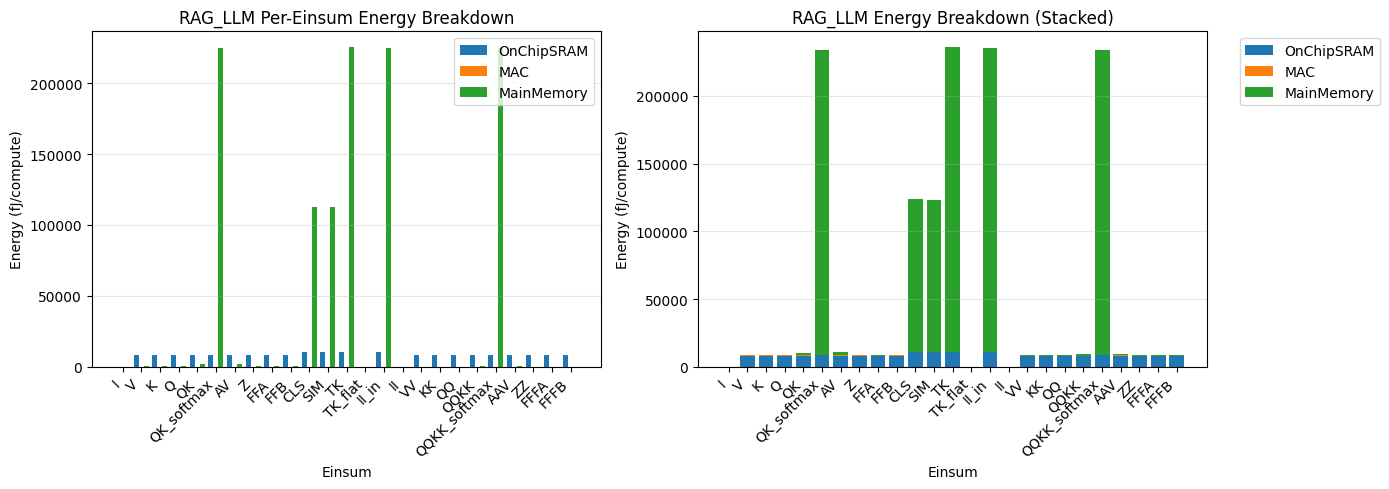

In [14]:
plot_data = {}
for name, result in results.items():
    result.clear_zero_energies()
    plot_data[name] = {k: v * 1e15 for k, v in result.per_compute('per_component_energy').items()}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Side-by-side bar chart
bar_side_by_side(
    plot_data,
    title='RAG_LLM Per-Einsum Energy Breakdown',
    xlabel='Einsum',
    ylabel='Energy (fJ/compute)',
    ax=axes[0]
)

# Stacked bar chart for better comparison
bar_stacked(
    plot_data,
    title='RAG_LLM Energy Breakdown (Stacked)',
    xlabel='Einsum',
    ylabel='Energy (fJ/compute)',
    ax=axes[1]
)
plt.tight_layout()
plt.show()

## Step 7: Analysis Helper Functions

These functions encapsulate the mapping logic so we can run parameter sweeps efficiently.

In [18]:
def run_rag_workload(rag_params, arch_overrides, einsum_names=None):
    """
    Run the RAG workload with given parameters, returning results for each einsum.
    
    Parameters
    ----------
    rag_params : dict
        Workload parameters (N_DOCS, T_TOKENS, K_DOCS, VOCAB_SIZE)
    arch_overrides : dict
        Architecture parameters (DRAM_SIZE_GB, SRAM_SIZE_MB, etc.)
    einsum_names : list, optional
        Which einsums to run. If None, runs all.
    
    Returns
    -------
    dict[str, Result]
        Results keyed by einsum name
    """
    workload = af.Workload.from_yaml(
        WORKLOAD_PATH,
        top_key='workload',
        jinja_parse_data=rag_params,
    )
    # renames = af.Renames.from_yaml(
    #     WORKLOAD_PATH,
    #     top_key='renames',
    #     jinja_parse_data=rag_params,
    # )
    
    results = {}
    for einsum in workload.einsums:
        if einsum_names is not None and einsum.name not in einsum_names:
            continue
            
        spec = get_spec('basic8', add_dummy_main_memory=False, jinja_parse_data=arch_overrides)
        spec.workload = af.Workload(
            einsums=[einsum],
            rank_sizes=workload.rank_sizes,
            bits_per_value=workload.bits_per_value,
            persistent_tensors=workload.persistent_tensors,
        )
        # spec.renames = renames
        spec.mapper.max_pmapping_templates_per_einsum = 1
        round_rank_sizes(spec.workload)
        spec.mapper.metrics = af.mapper.Metrics.ENERGY
        
        mappings = spec.map_workload_to_arch(print_progress=False, print_number_of_pmappings=False)
        results[einsum.name] = Result(mappings, variables=rag_params)
    
    return results


def aggregate_results(results):
    """
    Aggregate per-einsum results into total energy and per-component breakdown.
    
    Returns
    -------
    dict with keys:
        'total_energy_J': float
        'total_computes': int
        'per_component_energy_J': dict[str, float]
        'per_einsum_energy_J': dict[str, float]
        'per_einsum_computes': dict[str, int]
    """
    total_energy = 0
    total_computes = 0
    per_component = defaultdict(float)
    per_einsum_energy = {}
    per_einsum_computes = {}
    
    for name, result in results.items():
        result.clear_zero_energies()
        einsum_energy = sum(result.per_component_energy.values())
        einsum_computes = result.computes
        
        total_energy += einsum_energy
        total_computes += einsum_computes
        per_einsum_energy[name] = einsum_energy
        per_einsum_computes[name] = einsum_computes
        
        for comp, energy in result.per_component_energy.items():
            per_component[comp] += energy
    
    return {
        'total_energy_J': total_energy,
        'total_computes': total_computes,
        'per_component_energy_J': dict(per_component),
        'per_einsum_energy_J': per_einsum_energy,
        'per_einsum_computes': per_einsum_computes,
    }


def get_latency_from_mappings(results):
    """
    Extract latency information from results.
    Note: This requires re-running with LATENCY metric or extracting from mappings.
    For now, we estimate based on bandwidth and data movement.
    """
    # AccelForge Result doesn't directly expose latency in the current wrapper
    # We'll compute estimated latency from energy and bandwidth assumptions
    pass

print("Helper functions defined.")

Helper functions defined.


## Step 8: Initial Bottleneck Analysis

Before sweeping parameters, let's understand what the baseline results tell us about bottlenecks.

In [19]:
# Analyze bottlenecks from the baseline run
print("=" * 80)
print("BOTTLENECK ANALYSIS: Baseline Configuration")
print(f"N_DOCS={rag_params['N_DOCS']}, T_TOKENS={rag_params['N_TOKENS']}, K_DOCS={rag_params['K']}")
print("=" * 80)

# Aggregate results
agg = aggregate_results(results)

# 1. Which einsums dominate total energy?
print("\n1. EINSUM ENERGY BREAKDOWN (sorted by energy)")
print("-" * 60)
sorted_einsums = sorted(agg['per_einsum_energy_J'].items(), key=lambda x: x[1], reverse=True)
for name, energy in sorted_einsums:
    pct = 100 * energy / agg['total_energy_J'] if agg['total_energy_J'] > 0 else 0
    print(f"  {name:<12} {energy*1e9:>10.2f} nJ  ({pct:>5.1f}%)")

print(f"\n  TOTAL:      {agg['total_energy_J']*1e9:>10.2f} nJ")

# 2. Which architectural components dominate?
print("\n2. COMPONENT ENERGY BREAKDOWN (sorted by energy)")
print("-" * 60)
sorted_components = sorted(agg['per_component_energy_J'].items(), key=lambda x: x[1], reverse=True)
for comp, energy in sorted_components:
    pct = 100 * energy / agg['total_energy_J'] if agg['total_energy_J'] > 0 else 0
    print(f"  {comp:<15} {energy*1e9:>10.2f} nJ  ({pct:>5.1f}%)")

# 3. Identify the bottleneck
print("\n3. KEY INSIGHTS")
print("-" * 60)
top_einsum = sorted_einsums[0][0] if sorted_einsums else None
top_component = sorted_components[0][0] if sorted_components else None
print(f"  - Highest energy einsum: {top_einsum}")
print(f"  - Highest energy component: {top_component}")

# 4. Per-einsum component breakdown for top consumers
print("\n4. COMPONENT BREAKDOWN FOR TOP ENERGY CONSUMERS")
print("-" * 60)
for name, _ in sorted_einsums[:3]:  # Top 3
    result = results[name]
    result.clear_zero_energies()
    print(f"\n  {name}:")
    for comp, energy in sorted(result.per_component_energy.items(), key=lambda x: x[1], reverse=True):
        total_einsum = sum(result.per_component_energy.values())
        pct = 100 * energy / total_einsum if total_einsum > 0 else 0
        print(f"    {comp:<15} {energy*1e9:>8.2f} nJ  ({pct:>5.1f}%)")

BOTTLENECK ANALYSIS: Baseline Configuration
N_DOCS=1024, T_TOKENS=512, K_DOCS=10

1. EINSUM ENERGY BREAKDOWN (sorted by energy)
------------------------------------------------------------
  FFFB         31501573217.23 nJ  ( 30.3%)
  FFFA         31435098107.57 nJ  ( 30.2%)
  VV           7875147971.59 nJ  (  7.6%)
  KK           7875147971.59 nJ  (  7.6%)
  QQ           7875147971.59 nJ  (  7.6%)
  ZZ           7875147971.59 nJ  (  7.6%)
  AAV          4331518948.04 nJ  (  4.2%)
  QQKK         4323201512.76 nJ  (  4.2%)
  QQKK_softmax 846654022.83 nJ  (  0.8%)
  II_in        17796063.66 nJ  (  0.0%)
  FFB          10647427.22 nJ  (  0.0%)
  FFA          10644662.13 nJ  (  0.0%)
  Z            2695028.52 nJ  (  0.0%)
  V            2695028.51 nJ  (  0.0%)
  K            2695028.51 nJ  (  0.0%)
  Q            2695028.51 nJ  (  0.0%)
  AV           2142533.31 nJ  (  0.0%)
  QK           2136081.42 nJ  (  0.0%)
  QK_softmax    734942.71 nJ  (  0.0%)
  TK            123696.45 nJ  (  0.0%)


## Step 9: Sweep Number of Documents (N_DOCS)

This experiment varies the RAG corpus size to understand how retrieval scales.

In [20]:
# Sweep N_DOCS: Number of documents in the RAG corpus
N_DOCS_VALUES = [256, 512, 1024, 2048, 4096]

sweep_n_docs_results = {}

print("Sweeping N_DOCS...")
for n_docs in N_DOCS_VALUES:
    print(f"  N_DOCS = {n_docs}...", end=" ")
    
    params = {
        # 'VOCAB_SIZE': 32000,
        'N_DOCS': n_docs,
        'N_TOKENS': 512,
        'K': 10,
    }
    
    results_sweep = run_rag_workload(params, arch_overrides)
    sweep_n_docs_results[n_docs] = {
        'results': results_sweep,
        'aggregated': aggregate_results(results_sweep),
    }
    print(f"Total energy: {sweep_n_docs_results[n_docs]['aggregated']['total_energy_J']*1e9:.2f} nJ")

print("Done.")

Sweeping N_DOCS...
  N_DOCS = 256... Total energy: 103993623388.38 nJ
  N_DOCS = 512... Total energy: 103993678568.89 nJ
  N_DOCS = 1024... Total energy: 103993788929.93 nJ
  N_DOCS = 2048... Total energy: 103994009652.01 nJ
  N_DOCS = 4096... Total energy: 103994451096.17 nJ
Done.


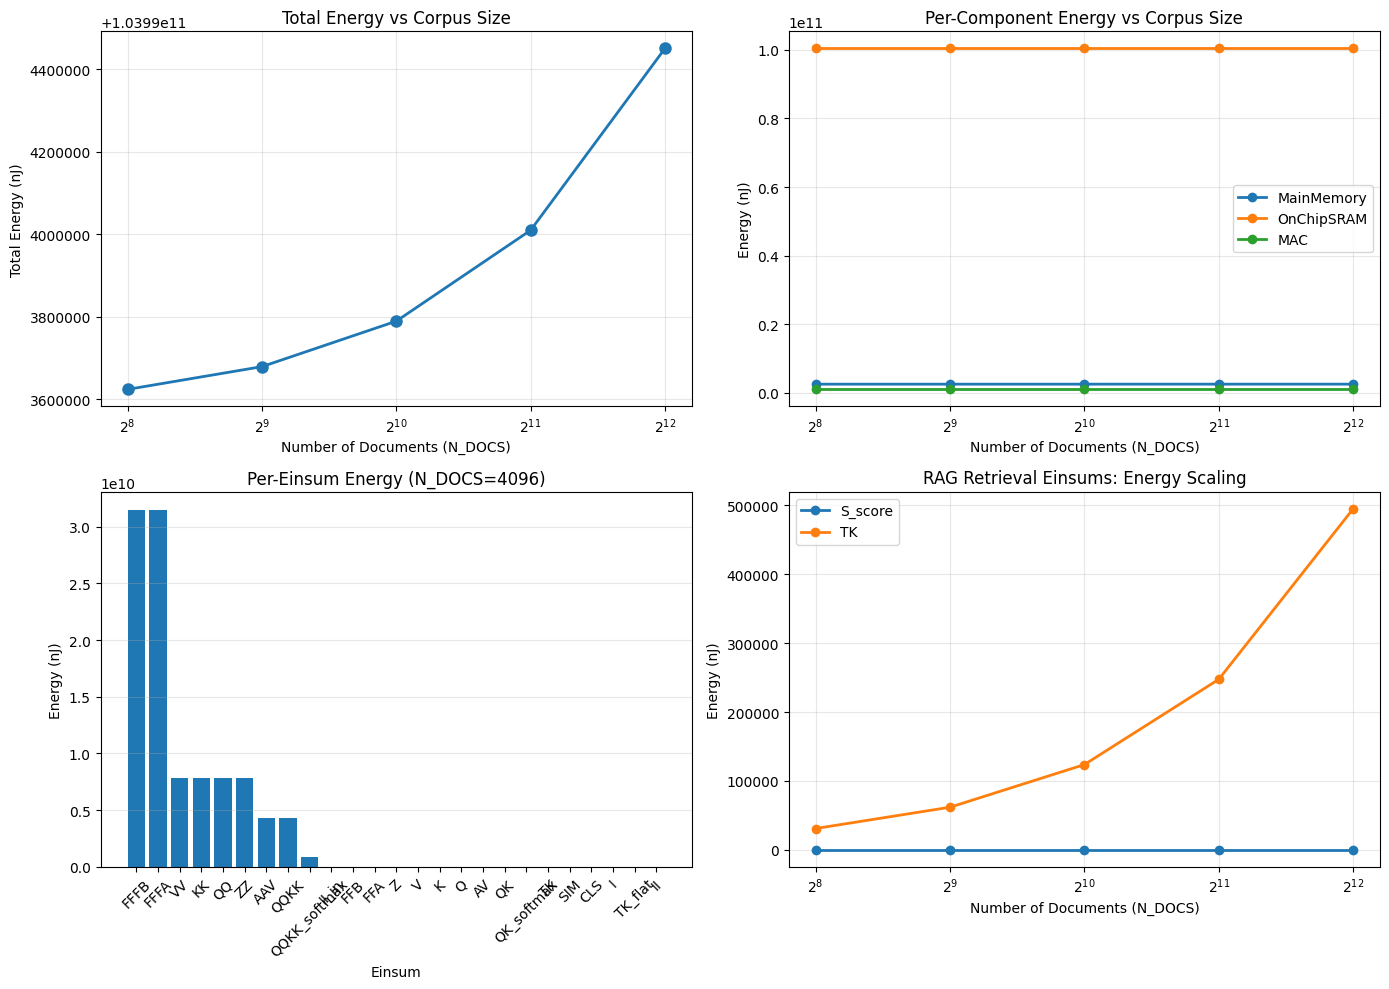

In [21]:
# Plot N_DOCS sweep results
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Total energy vs N_DOCS
ax1 = axes[0, 0]
n_docs_list = list(sweep_n_docs_results.keys())
total_energies = [sweep_n_docs_results[n]['aggregated']['total_energy_J'] * 1e9 for n in n_docs_list]
ax1.plot(n_docs_list, total_energies, 'o-', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Documents (N_DOCS)')
ax1.set_ylabel('Total Energy (nJ)')
ax1.set_title('Total Energy vs Corpus Size')
ax1.set_xscale('log', base=2)
ax1.grid(True, alpha=0.3)

# 2. Per-component energy vs N_DOCS
ax2 = axes[0, 1]
components = ['MainMemory', 'OnChipSRAM', 'MAC']
for comp in components:
    energies = [sweep_n_docs_results[n]['aggregated']['per_component_energy_J'].get(comp, 0) * 1e9 
                for n in n_docs_list]
    ax2.plot(n_docs_list, energies, 'o-', label=comp, linewidth=2, markersize=6)
ax2.set_xlabel('Number of Documents (N_DOCS)')
ax2.set_ylabel('Energy (nJ)')
ax2.set_title('Per-Component Energy vs Corpus Size')
ax2.set_xscale('log', base=2)
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Per-einsum energy for largest N_DOCS
ax3 = axes[1, 0]
largest_n = max(n_docs_list)
einsum_energies = sweep_n_docs_results[largest_n]['aggregated']['per_einsum_energy_J']
sorted_einsums = sorted(einsum_energies.items(), key=lambda x: x[1], reverse=True)
names = [e[0] for e in sorted_einsums]
energies = [e[1] * 1e9 for e in sorted_einsums]
bars = ax3.bar(names, energies)
ax3.set_xlabel('Einsum')
ax3.set_ylabel('Energy (nJ)')
ax3.set_title(f'Per-Einsum Energy (N_DOCS={largest_n})')
ax3.tick_params(axis='x', rotation=45)
ax3.grid(axis='y', alpha=0.3)

# 4. S_score and TK energy scaling (RAG-specific einsums)
ax4 = axes[1, 1]
rag_einsums = ['S_score', 'TK']
for einsum_name in rag_einsums:
    energies = [sweep_n_docs_results[n]['aggregated']['per_einsum_energy_J'].get(einsum_name, 0) * 1e9 
                for n in n_docs_list]
    ax4.plot(n_docs_list, energies, 'o-', label=einsum_name, linewidth=2, markersize=6)
ax4.set_xlabel('Number of Documents (N_DOCS)')
ax4.set_ylabel('Energy (nJ)')
ax4.set_title('RAG Retrieval Einsums: Energy Scaling')
ax4.set_xscale('log', base=2)
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Step 10: Sweep Document Size (T_TOKENS)

This experiment varies the token length to understand how document size affects energy.

In [22]:
# Sweep T_TOKENS: Document/query token length
T_TOKENS_VALUES = [128, 256, 512, 1024, 2048]

sweep_t_tokens_results = {}

print("Sweeping T_TOKENS...")
for t_tokens in T_TOKENS_VALUES:
    print(f"  T_TOKENS = {t_tokens}...", end=" ")
    
    params = {
        # 'VOCAB_SIZE': 32000,
        'N_DOCS': 1024,
        'N_TOKENS': t_tokens,
        'K': 10,
    }
    
    results_sweep = run_rag_workload(params, arch_overrides)
    sweep_t_tokens_results[t_tokens] = {
        'results': results_sweep,
        'aggregated': aggregate_results(results_sweep),
    }
    print(f"Total energy: {sweep_t_tokens_results[t_tokens]['aggregated']['total_energy_J']*1e9:.2f} nJ")

print("Done.")

Sweeping T_TOKENS...
  T_TOKENS = 128... Total energy: 103965641405.50 nJ
  T_TOKENS = 256... Total energy: 103974419679.17 nJ
  T_TOKENS = 512... Total energy: 103993788929.93 nJ
  T_TOKENS = 1024... Total energy: 104039778246.78 nJ
  T_TOKENS = 2048... Total energy: 104160760139.67 nJ
Done.


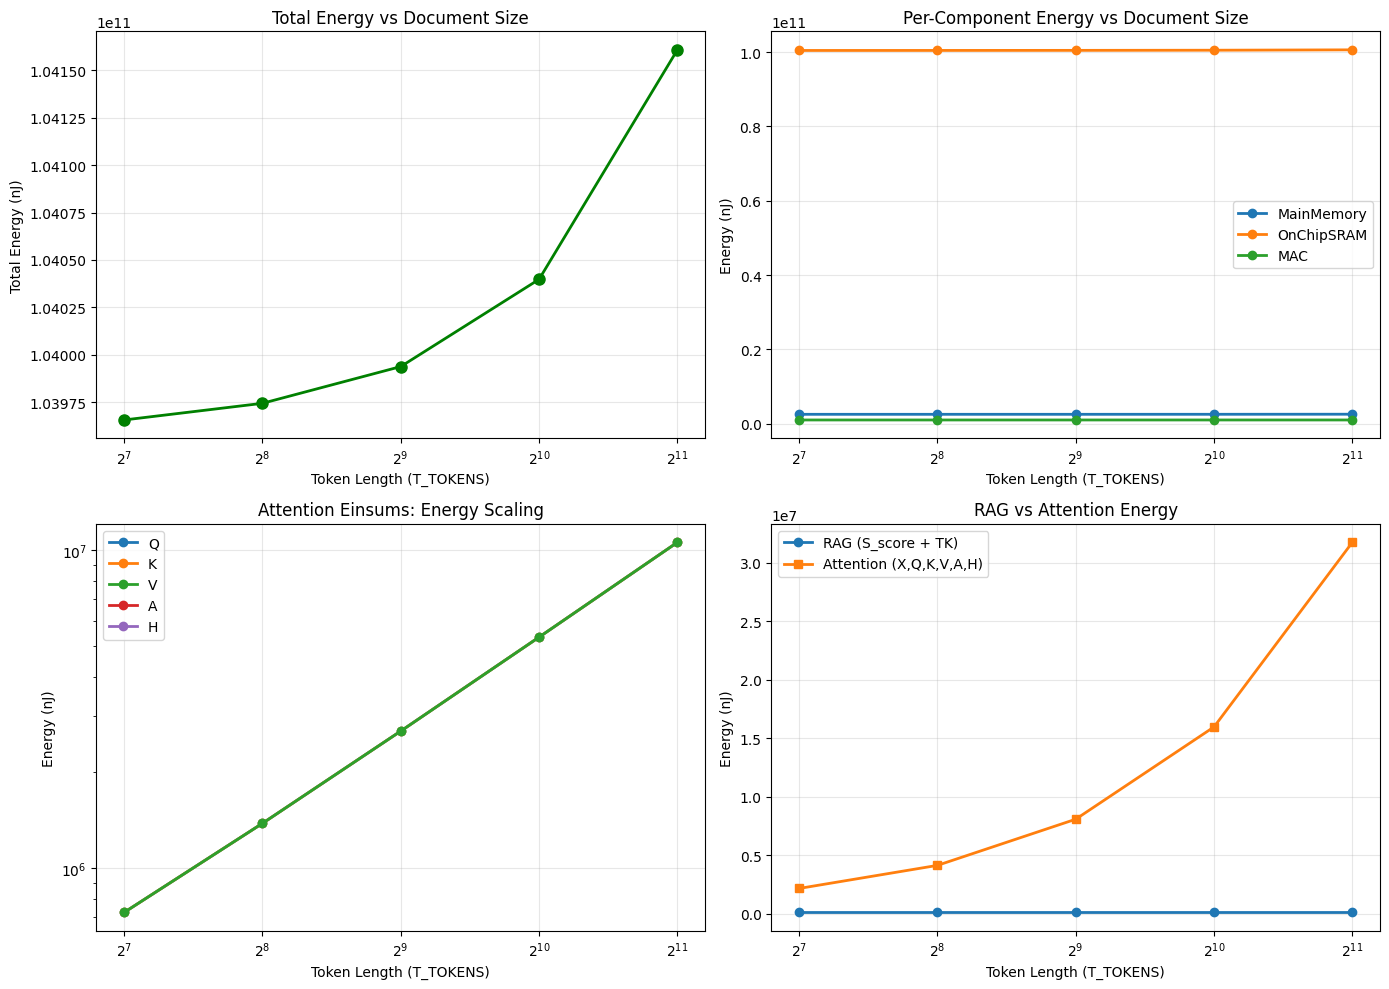

In [23]:
# Plot T_TOKENS sweep results
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

t_tokens_list = list(sweep_t_tokens_results.keys())

# 1. Total energy vs T_TOKENS
ax1 = axes[0, 0]
total_energies = [sweep_t_tokens_results[t]['aggregated']['total_energy_J'] * 1e9 for t in t_tokens_list]
ax1.plot(t_tokens_list, total_energies, 'o-', linewidth=2, markersize=8, color='green')
ax1.set_xlabel('Token Length (T_TOKENS)')
ax1.set_ylabel('Total Energy (nJ)')
ax1.set_title('Total Energy vs Document Size')
ax1.set_xscale('log', base=2)
ax1.grid(True, alpha=0.3)

# 2. Per-component energy vs T_TOKENS
ax2 = axes[0, 1]
for comp in components:
    energies = [sweep_t_tokens_results[t]['aggregated']['per_component_energy_J'].get(comp, 0) * 1e9 
                for t in t_tokens_list]
    ax2.plot(t_tokens_list, energies, 'o-', label=comp, linewidth=2, markersize=6)
ax2.set_xlabel('Token Length (T_TOKENS)')
ax2.set_ylabel('Energy (nJ)')
ax2.set_title('Per-Component Energy vs Document Size')
ax2.set_xscale('log', base=2)
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Attention einsums (Q, K, V, A, H) scaling with T_TOKENS
ax3 = axes[1, 0]
attention_einsums = ['Q', 'K', 'V', 'A', 'H']
for einsum_name in attention_einsums:
    energies = [sweep_t_tokens_results[t]['aggregated']['per_einsum_energy_J'].get(einsum_name, 0) * 1e9 
                for t in t_tokens_list]
    ax3.plot(t_tokens_list, energies, 'o-', label=einsum_name, linewidth=2, markersize=6)
ax3.set_xlabel('Token Length (T_TOKENS)')
ax3.set_ylabel('Energy (nJ)')
ax3.set_title('Attention Einsums: Energy Scaling')
ax3.set_xscale('log', base=2)
ax3.set_yscale('log')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. RAG vs Attention energy comparison
ax4 = axes[1, 1]
rag_total = [sum(sweep_t_tokens_results[t]['aggregated']['per_einsum_energy_J'].get(e, 0) 
                 for e in ['S_score', 'TK']) * 1e9 for t in t_tokens_list]
attn_total = [sum(sweep_t_tokens_results[t]['aggregated']['per_einsum_energy_J'].get(e, 0) 
                  for e in ['X', 'Q', 'K', 'V', 'A', 'H']) * 1e9 for t in t_tokens_list]
ax4.plot(t_tokens_list, rag_total, 'o-', label='RAG (S_score + TK)', linewidth=2, markersize=6)
ax4.plot(t_tokens_list, attn_total, 's-', label='Attention (X,Q,K,V,A,H)', linewidth=2, markersize=6)
ax4.set_xlabel('Token Length (T_TOKENS)')
ax4.set_ylabel('Energy (nJ)')
ax4.set_title('RAG vs Attention Energy')
ax4.set_xscale('log', base=2)
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Step 11: 2D Heatmap — N_DOCS × T_TOKENS

Comprehensive analysis of how both parameters interact.

In [24]:
# 2D sweep: N_DOCS × T_TOKENS
N_DOCS_GRID = [256, 512, 1024, 2048]
T_TOKENS_GRID = [128, 256, 512, 1024]

sweep_2d_results = {}

print("Running 2D sweep (N_DOCS × T_TOKENS)...")
for n_docs in N_DOCS_GRID:
    for t_tokens in T_TOKENS_GRID:
        print(f"  N_DOCS={n_docs}, T_TOKENS={t_tokens}...", end=" ")
        
        params = {
            # 'VOCAB_SIZE': 32000,
            'N_DOCS': n_docs,
            'N_TOKENS': t_tokens,
            'K': 10,
        }
        
        results_sweep = run_rag_workload(params, arch_overrides)
        sweep_2d_results[(n_docs, t_tokens)] = {
            'results': results_sweep,
            'aggregated': aggregate_results(results_sweep),
        }
        print(f"done")

print("2D sweep complete.")

Running 2D sweep (N_DOCS × T_TOKENS)...
  N_DOCS=256, T_TOKENS=128... done
  N_DOCS=256, T_TOKENS=256... done
  N_DOCS=256, T_TOKENS=512... done
  N_DOCS=256, T_TOKENS=1024... done
  N_DOCS=512, T_TOKENS=128... done
  N_DOCS=512, T_TOKENS=256... done
  N_DOCS=512, T_TOKENS=512... done
  N_DOCS=512, T_TOKENS=1024... done
  N_DOCS=1024, T_TOKENS=128... done
  N_DOCS=1024, T_TOKENS=256... done
  N_DOCS=1024, T_TOKENS=512... done
  N_DOCS=1024, T_TOKENS=1024... done
  N_DOCS=2048, T_TOKENS=128... done
  N_DOCS=2048, T_TOKENS=256... done
  N_DOCS=2048, T_TOKENS=512... done
  N_DOCS=2048, T_TOKENS=1024... done
2D sweep complete.


## Step 12: Prefill vs Decode Stage Analysis

In LLMs, **prefill** processes the full input context (Q, K, V computation), while **decode** generates tokens one at a time. In RAG, we can categorize:

- **Prefill-like**: Token embedding (X), QKV projections, Attention (A, P, H)
- **Retrieval**: Similarity search (S_score), document fetch (TK)
- **Decode** would require modeling auto-regressive token generation (not in current workload)

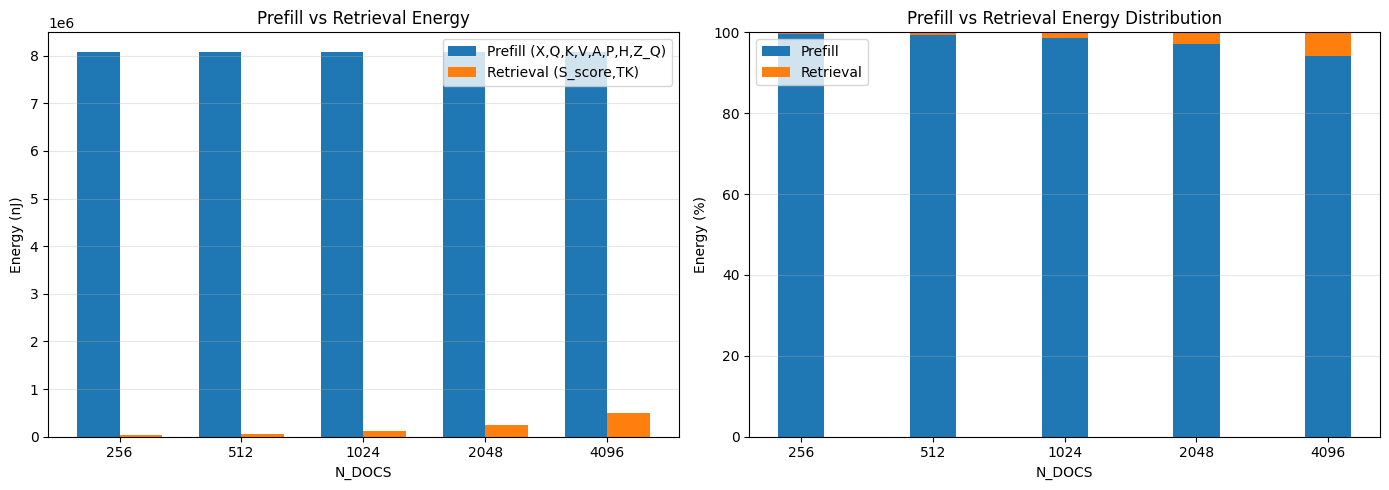


Prefill vs Retrieval Summary:
------------------------------------------------------------
N_DOCS     Prefill (nJ)    Retrieval (nJ)  Retrieval % 
------------------------------------------------------------
256        8085085.52      30924.11        0.4         
512        8085085.52      61848.23        0.8         
1024       8085085.52      123696.45       1.5         
2048       8085085.52      247392.90       3.0         
4096       8085085.52      494785.81       5.8         


In [25]:
# Categorize einsums into stages
PREFILL_EINSUMS = ['X', 'Q', 'K', 'V', 'A', 'P', 'H', 'Z_Q']
RETRIEVAL_EINSUMS = ['S_score', 'TK']

def categorize_energy(aggregated):
    """Split energy by stage."""
    prefill = sum(aggregated['per_einsum_energy_J'].get(e, 0) for e in PREFILL_EINSUMS)
    retrieval = sum(aggregated['per_einsum_energy_J'].get(e, 0) for e in RETRIEVAL_EINSUMS)
    return {'Prefill': prefill, 'Retrieval': retrieval}

# Analyze stages across N_DOCS sweep
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Absolute energy by stage
ax1 = axes[0]
prefill_energies = []
retrieval_energies = []
for n_docs in N_DOCS_VALUES:
    cat = categorize_energy(sweep_n_docs_results[n_docs]['aggregated'])
    prefill_energies.append(cat['Prefill'] * 1e9)
    retrieval_energies.append(cat['Retrieval'] * 1e9)

x = np.arange(len(N_DOCS_VALUES))
width = 0.35
ax1.bar(x - width/2, prefill_energies, width, label='Prefill (X,Q,K,V,A,P,H,Z_Q)')
ax1.bar(x + width/2, retrieval_energies, width, label='Retrieval (S_score,TK)')
ax1.set_xlabel('N_DOCS')
ax1.set_ylabel('Energy (nJ)')
ax1.set_title('Prefill vs Retrieval Energy')
ax1.set_xticks(x)
ax1.set_xticklabels(N_DOCS_VALUES)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Plot 2: Percentage breakdown
ax2 = axes[1]
prefill_pct = []
retrieval_pct = []
for n_docs in N_DOCS_VALUES:
    cat = categorize_energy(sweep_n_docs_results[n_docs]['aggregated'])
    total = cat['Prefill'] + cat['Retrieval']
    prefill_pct.append(100 * cat['Prefill'] / total if total > 0 else 0)
    retrieval_pct.append(100 * cat['Retrieval'] / total if total > 0 else 0)

ax2.bar(x, prefill_pct, width, label='Prefill')
ax2.bar(x, retrieval_pct, width, bottom=prefill_pct, label='Retrieval')
ax2.set_xlabel('N_DOCS')
ax2.set_ylabel('Energy (%)')
ax2.set_title('Prefill vs Retrieval Energy Distribution')
ax2.set_xticks(x)
ax2.set_xticklabels(N_DOCS_VALUES)
ax2.legend()
ax2.set_ylim(0, 100)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary
print("\nPrefill vs Retrieval Summary:")
print("-" * 60)
print(f"{'N_DOCS':<10} {'Prefill (nJ)':<15} {'Retrieval (nJ)':<15} {'Retrieval %':<12}")
print("-" * 60)
for i, n_docs in enumerate(N_DOCS_VALUES):
    print(f"{n_docs:<10} {prefill_energies[i]:<15.2f} {retrieval_energies[i]:<15.2f} {retrieval_pct[i]:<12.1f}")

## Step 13: Summary Report — Bottleneck Analysis

In [26]:
print("=" * 80)
print("MILESTONE 2 SUMMARY: RAG Bottleneck Analysis")
print("=" * 80)

print("""
ARCHITECTURE: basic8 (TPUv4i-like with Disk)
  - Disk: Infinite, zero energy (offline embedding)
  - MainMemory (DRAM): 8 GB LPDDR5, 68 GB/s, 7.03 pJ/access
  - OnChipSRAM: 8 MB, 512/128 GB/s read/write
  - MAC: FP16, 0.084 pJ/op

WORKLOAD: RAG_LLM
  - Embed tokens → QKV → Attention → Similarity → Top-K
""")

print("\n" + "=" * 80)
print("KEY FINDINGS (from baseline: N_DOCS=1024, T_TOKENS=512)")
print("=" * 80)

# Use baseline results for analysis
agg = aggregate_results(results)
sorted_einsums = sorted(agg['per_einsum_energy_J'].items(), key=lambda x: x[1], reverse=True)
sorted_components = sorted(agg['per_component_energy_J'].items(), key=lambda x: x[1], reverse=True)

print(f"""
1. ARCHITECTURAL BOTTLENECK: {sorted_components[0][0]}
   - Accounts for {100*sorted_components[0][1]/agg['total_energy_J']:.1f}% of total energy

2. EINSUM BOTTLENECK: {sorted_einsums[0][0]}
   - Accounts for {100*sorted_einsums[0][1]/agg['total_energy_J']:.1f}% of total energy
""")

# Analyze bottleneck shifts from ACTUAL sweep data
print("=" * 80)
print("BOTTLENECK SHIFTS (derived from sweep data)")
print("=" * 80)

print("\n3. N_DOCS SWEEP ANALYSIS:")
print("-" * 60)
for n_docs in N_DOCS_VALUES:
    agg_n = sweep_n_docs_results[n_docs]['aggregated']
    
    # Top einsum
    top_einsum = max(agg_n['per_einsum_energy_J'].items(), key=lambda x: x[1])
    top_einsum_pct = 100 * top_einsum[1] / agg_n['total_energy_J']
    
    # Top component
    top_comp = max(agg_n['per_component_energy_J'].items(), key=lambda x: x[1])
    top_comp_pct = 100 * top_comp[1] / agg_n['total_energy_J']
    
    # Retrieval vs Prefill
    retrieval_e = agg_n['per_einsum_energy_J'].get('S_score', 0) + agg_n['per_einsum_energy_J'].get('TK', 0)
    prefill_e = sum(agg_n['per_einsum_energy_J'].get(e, 0) for e in ['X', 'Q', 'K', 'V', 'A', 'H'])
    retrieval_pct = 100 * retrieval_e / agg_n['total_energy_J']
    
    print(f"  N_DOCS={n_docs:>4}: Top einsum={top_einsum[0]:<8} ({top_einsum_pct:>5.1f}%), "
          f"Top component={top_comp[0]:<12} ({top_comp_pct:>5.1f}%), Retrieval={retrieval_pct:>5.1f}%")

print("\n4. T_TOKENS SWEEP ANALYSIS:")
print("-" * 60)
for t_tokens in T_TOKENS_VALUES:
    agg_t = sweep_t_tokens_results[t_tokens]['aggregated']
    
    # Top einsum
    top_einsum = max(agg_t['per_einsum_energy_J'].items(), key=lambda x: x[1])
    top_einsum_pct = 100 * top_einsum[1] / agg_t['total_energy_J']
    
    # A (attention) energy
    a_energy = agg_t['per_einsum_energy_J'].get('A', 0) * 1e9
    
    print(f"  T_TOKENS={t_tokens:>4}: Top einsum={top_einsum[0]:<8} ({top_einsum_pct:>5.1f}%), "
          f"A energy={a_energy:>10.2f} nJ")

# Check quadratic scaling of A
print("\n5. ATTENTION (A) SCALING CHECK:")
print("-" * 60)
a_energies = [sweep_t_tokens_results[t]['aggregated']['per_einsum_energy_J'].get('A', 0) for t in T_TOKENS_VALUES]
for i in range(1, len(T_TOKENS_VALUES)):
    t_ratio = T_TOKENS_VALUES[i] / T_TOKENS_VALUES[i-1]
    e_ratio = a_energies[i] / a_energies[i-1] if a_energies[i-1] > 0 else 0
    expected = t_ratio ** 2  # quadratic scaling
    print(f"  T: {T_TOKENS_VALUES[i-1]} → {T_TOKENS_VALUES[i]} (×{t_ratio:.1f}): "
          f"A energy ratio = {e_ratio:.2f}× (expected ×{expected:.1f} if quadratic)")

# Create a final summary DataFrame
print("\n" + "=" * 80)
print("DETAILED BREAKDOWN TABLE")
print("=" * 80)

summary_data = []
for name, energy in sorted_einsums:
    computes = agg['per_einsum_computes'][name]
    pj_per_compute = (energy / computes * 1e12) if computes > 0 else 0
    result = results[name]
    result.clear_zero_energies()
    top_component = max(result.per_component_energy.items(), key=lambda x: x[1])[0] if result.per_component_energy else 'N/A'
    summary_data.append({
        'Einsum': name,
        'Energy (nJ)': energy * 1e9,
        '% of Total': 100 * energy / agg['total_energy_J'],
        'Computes': computes,
        'pJ/compute': pj_per_compute,
        'Top Component': top_component,
    })

df = pd.DataFrame(summary_data)
print(df.to_string(index=False))

MILESTONE 2 SUMMARY: RAG Bottleneck Analysis

ARCHITECTURE: basic8 (TPUv4i-like with Disk)
  - Disk: Infinite, zero energy (offline embedding)
  - MainMemory (DRAM): 8 GB LPDDR5, 68 GB/s, 7.03 pJ/access
  - OnChipSRAM: 8 MB, 512/128 GB/s read/write
  - MAC: FP16, 0.084 pJ/op

WORKLOAD: RAG_LLM
  - Embed tokens → QKV → Attention → Similarity → Top-K


KEY FINDINGS (from baseline: N_DOCS=1024, T_TOKENS=512)

1. ARCHITECTURAL BOTTLENECK: OnChipSRAM
   - Accounts for 96.6% of total energy

2. EINSUM BOTTLENECK: FFFB
   - Accounts for 30.3% of total energy

BOTTLENECK SHIFTS (derived from sweep data)

3. N_DOCS SWEEP ANALYSIS:
------------------------------------------------------------
  N_DOCS= 256: Top einsum=FFFB     ( 30.3%), Top component=OnChipSRAM   ( 96.6%), Retrieval=  0.0%
  N_DOCS= 512: Top einsum=FFFB     ( 30.3%), Top component=OnChipSRAM   ( 96.6%), Retrieval=  0.0%
  N_DOCS=1024: Top einsum=FFFB     ( 30.3%), Top component=OnChipSRAM   ( 96.6%), Retrieval=  0.0%
  N_DOCS=204